<a href="https://colab.research.google.com/github/kristinalusiana24-sketch/Post-Test-PrakAlprog-2026/blob/main/Grafik%204%20(Kategori%20D).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

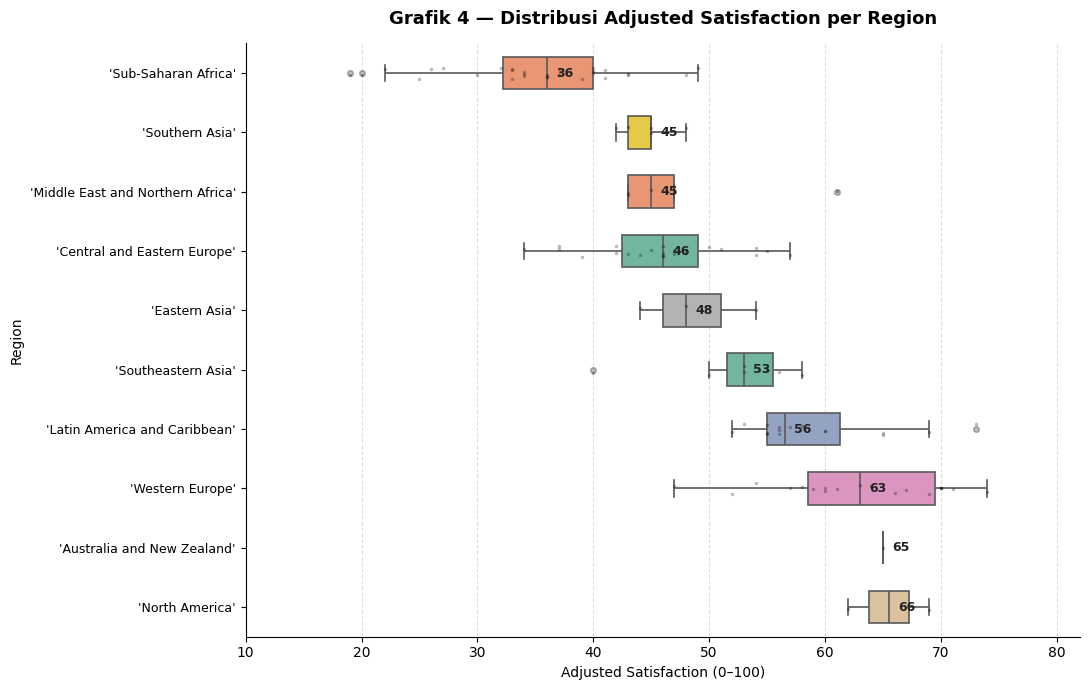

In [2]:
# GRAFIK 4 — Kategori D (versi horizontal, label tidak miring)
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('/content/Kelas D_Happiness and Satisfaction.csv', sep=';')
fig4, ax4 = plt.subplots(figsize=(11, 7))

df4 = df[['Region', 'adjusted_satisfaction (0-100)']].dropna()
region_order = (df4.groupby('Region')['adjusted_satisfaction (0-100)']
                .median().sort_values(ascending=True).index.tolist())
palette_d = sns.color_palette('Set2', n_colors=len(region_order))

sns.boxplot(
    data=df4, y='Region', x='adjusted_satisfaction (0-100)',
    order=region_order, hue='Region', palette=palette_d,
    legend=False, width=0.55, linewidth=1.2,
    flierprops=dict(marker='o', markersize=4, alpha=0.5,
                    markerfacecolor='gray', linestyle='none'),
    ax=ax4
)
sns.stripplot(
    data=df4, y='Region', x='adjusted_satisfaction (0-100)',
    order=region_order, color='black', size=2.5, alpha=0.28,
    jitter=True, ax=ax4
)

for i, region in enumerate(region_order):
    med = df4[df4['Region'] == region]['adjusted_satisfaction (0-100)'].median()
    ax4.text(med + 0.8, i, f'{med:.0f}',
             va='center', ha='left', fontsize=9, fontweight='bold', color='#222')

ax4.set_title('Grafik 4 — Distribusi Adjusted Satisfaction per Region',
              fontsize=13, fontweight='bold', pad=14)
ax4.set_ylabel('Region', fontsize=10)
ax4.set_xlabel('Adjusted Satisfaction (0–100)', fontsize=10)
ax4.set_xlim(10, df4['adjusted_satisfaction (0-100)'].max() + 8)
plt.setp(ax4.get_yticklabels(), fontsize=9)
ax4.spines[['top', 'right']].set_visible(False)
ax4.grid(axis='x', linestyle='--', alpha=0.4)
ax4.set_axisbelow(True)

plt.tight_layout()
plt.savefig('Grafik_4_KategoriD.png', dpi=150, bbox_inches='tight')
plt.show()